# Bluestock Fintech — Performance Analytics
**Day 4 Deliverable**  
Outputs: `fund_scorecard.csv`, `alpha_beta.csv`, benchmark comparison chart

In [1]:
import os
os.chdir(r'C:\Users\omc\mf_analysis')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED = 'data/processed'
CHARTS    = 'reports/charts'
os.makedirs(CHARTS, exist_ok=True)

RF_DAILY  = 0.065 / 252   # RBI repo rate proxy — 6.5% annualised
TRADING_DAYS = 252

def save_png(fig, name):
    path = os.path.join(CHARTS, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  ✓ Saved {name}')

print('Setup complete')

Setup complete


In [2]:
# ── Load datasets ─────────────────────────────────────────
nav    = pd.read_csv(f'{PROCESSED}/02_nav_history_clean.csv')
funds  = pd.read_csv(f'{PROCESSED}/01_fund_master_clean.csv')
bench  = pd.read_csv(f'{PROCESSED}/10_benchmark_indices_clean.csv')
perf   = pd.read_csv(f'{PROCESSED}/07_scheme_performance_clean.csv')

# Detect columns
date_col = [c for c in nav.columns if 'date' in c.lower()][0]
nav_col  = [c for c in nav.columns if c.lower() == 'nav' or c.lower() == 'nav_value'][0] if any(c.lower() in ['nav','nav_value'] for c in nav.columns) else [c for c in nav.columns if 'nav' in c.lower()][0]
code_col = [c for c in nav.columns if 'code' in c.lower() or 'amfi' in c.lower()][0]

nav[date_col] = pd.to_datetime(nav[date_col], errors='coerce')
nav[nav_col]  = pd.to_numeric(nav[nav_col], errors='coerce')
nav.dropna(subset=[date_col, nav_col], inplace=True)
nav.sort_values([code_col, date_col], inplace=True)
nav.reset_index(drop=True, inplace=True)

# Pivot to wide format: rows=date, cols=scheme_code
nav_wide = nav.pivot_table(index=date_col, columns=code_col, values=nav_col)

schemes = nav_wide.columns.tolist()
print(f'Loaded {len(schemes)} schemes | Date range: {nav_wide.index.min().date()} to {nav_wide.index.max().date()}')
print(f'NAV matrix shape: {nav_wide.shape}')

Loaded 40 schemes | Date range: 2022-01-03 to 2026-05-29
NAV matrix shape: (1150, 40)


---
## Step 1 — Daily Returns

Daily Returns — Distribution Check
amfi_code     100016     100025     100033     101206     101207     101208     102885     102886     102887     118632     118633     118634     118635     118636     119092     119093     119094     119095     119120     119551     119552     119598     119599     120503     120504     120505     120506     120507     120841     120842     120843     120844     125497     125498     148567     148568     148569     149322     149323     149324
count      1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000  1149.0000
mean          0.0001     0.0002     0.0011     0.0009     0.0004 

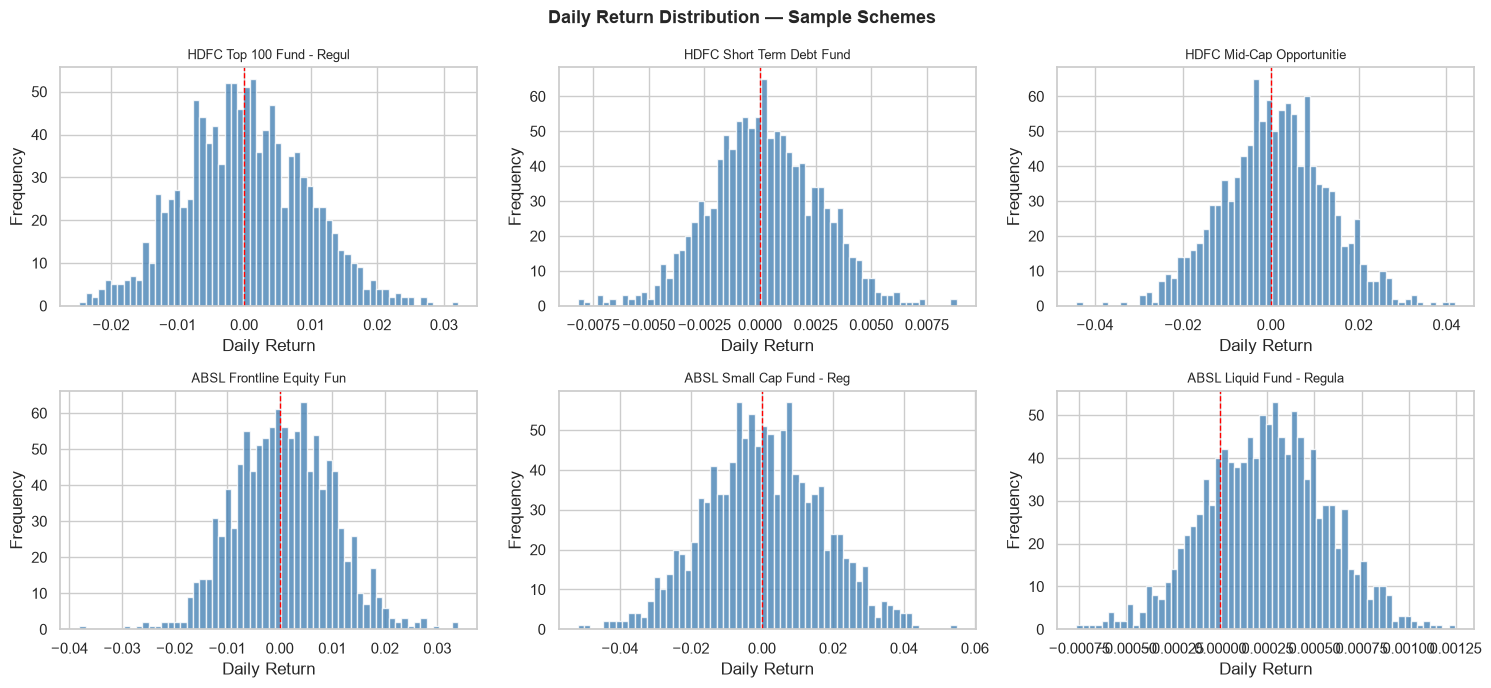


Returns shape: (1149, 40)
Mean daily return range: 0.0001 to 0.0012
Max single-day gain : 6.47%
Max single-day loss : -5.81%


In [3]:
# daily_return = NAV_t / NAV_t-1 - 1
returns = nav_wide.pct_change().dropna(how='all')

print('Daily Returns — Distribution Check')
print(returns.describe().round(4).to_string())

# Plot distribution for first 6 schemes
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, returns.columns[:6]):
    scheme_label = str(col)
    # Try to get scheme name
    if 'scheme_name' in funds.columns and code_col in funds.columns:
        name_map = funds.set_index(code_col)['scheme_name'].to_dict()
        scheme_label = str(name_map.get(col, col))[:25]
    ax.hist(returns[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(scheme_label, fontsize=9)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Frequency')

plt.suptitle('Daily Return Distribution — Sample Schemes', fontsize=13, fontweight='bold')
plt.tight_layout()
save_png(fig, '11_daily_return_distribution.png')
plt.show()

print(f'\nReturns shape: {returns.shape}')
print(f'Mean daily return range: {returns.mean().min():.4f} to {returns.mean().max():.4f}')
print(f'Max single-day gain : {returns.max().max():.2%}')
print(f'Max single-day loss : {returns.min().min():.2%}')

---
## Step 2 — CAGR (1yr, 3yr, 5yr)

In [4]:
def compute_cagr(nav_series, years):
    """CAGR = (NAV_end / NAV_start) ^ (1/n) - 1"""
    nav_clean = nav_series.dropna()
    if len(nav_clean) < 2:
        return np.nan
    end_date   = nav_clean.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    subset = nav_clean[nav_clean.index >= start_date]
    if len(subset) < 2:
        return np.nan
    nav_end   = subset.iloc[-1]
    nav_start = subset.iloc[0]
    if nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / years) - 1

cagr_rows = []
for code in schemes:
    s = nav_wide[code].dropna()
    cagr_rows.append({
        'scheme_code': code,
        'cagr_1yr':    compute_cagr(s, 1),
        'cagr_3yr':    compute_cagr(s, 3),
        'cagr_5yr':    compute_cagr(s, 5),
    })

cagr_df = pd.DataFrame(cagr_rows)

# Merge scheme names
if 'scheme_name' in funds.columns:
    name_col = 'scheme_name'
    fc = [c for c in funds.columns if 'code' in c.lower() or 'amfi' in c.lower()][0]
    cagr_df = cagr_df.merge(funds[[fc, name_col]], left_on='scheme_code', right_on=fc, how='left')

print('CAGR Comparison Table:')
display_cols = ['scheme_code'] + (['scheme_name'] if 'scheme_name' in cagr_df.columns else []) + ['cagr_1yr','cagr_3yr','cagr_5yr']
print(cagr_df[display_cols].sort_values('cagr_3yr', ascending=False).to_string(index=False))

CAGR Comparison Table:
 scheme_code                                           scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
      119094                   Axis Midcap Fund - Regular - Growth  0.222611  0.351118  0.244453
      148567         Mirae Asset Large Cap Fund - Regular - Growth  0.203607  0.340009  0.267993
      120504             ICICI Pru Bluechip Fund - Direct - Growth  0.130643  0.324874  0.202340
      100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.532324  0.324425  0.260741
      120505              ICICI Pru Midcap Fund - Regular - Growth  0.296047  0.317775  0.283768
      119551             SBI Bluechip Fund - Regular Plan - Growth  0.604373  0.304565  0.223849
      120843                Kotak Flexicap Fund - Regular - Growth  0.266571  0.295828  0.267425
      148569         Mirae Asset Tax Saver Fund - Regular - Growth  0.397518  0.291789  0.276299
      101206         ABSL Frontline Equity Fund - Regular - Growth  0.479241  0.289677  0.204427
      1

---
## Step 3 — Sharpe Ratio

Sharpe Ratio Ranking:
 scheme_code  sharpe_ratio
      148567      1.448291
      120843      1.306744
      148569      1.234930
      119551      1.208267
      120505      1.180101
      149323      1.132122
      100033      1.093699
      118632      1.081659
      101206      1.027213
      120504      1.026524
      119094      0.998231
      119552      0.953279
      149324      0.949796
      119598      0.945308
      148568      0.926287
      102885      0.817099
      120503      0.797973
      125497      0.775790
      118635      0.664857
      120506      0.648879
      118633      0.645207
      102887      0.619518
      120507      0.495723
      120841      0.494273
      149322      0.464037
      118634      0.448434
      125498      0.300612
      101207      0.162661
      119093      0.129614
      120842      0.076000
      119092      0.030785
      119599     -0.057187
      119095     -0.075974
      120844     -0.088747
      100016     -0.201517
      

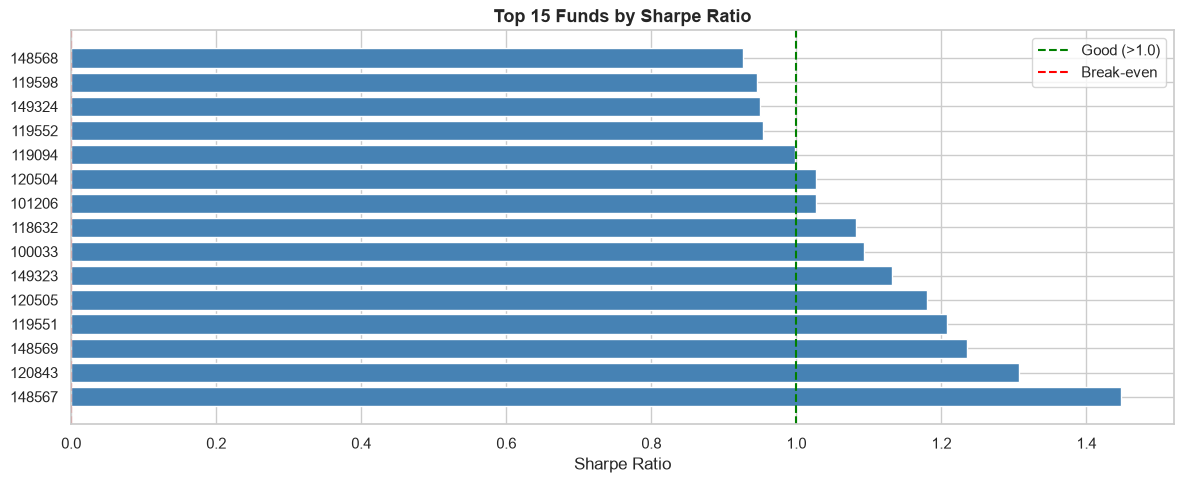

In [5]:
def sharpe_ratio(ret_series):
    """(Rp - Rf) / Std(Rp) * sqrt(252)"""
    r = ret_series.dropna()
    if len(r) < 30:
        return np.nan
    excess = r - RF_DAILY
    std    = r.std()
    if std == 0:
        return np.nan
    return (excess.mean() / std) * np.sqrt(TRADING_DAYS)

sharpe_rows = []
for code in schemes:
    sharpe_rows.append({
        'scheme_code': code,
        'sharpe_ratio': sharpe_ratio(returns[code])
    })

sharpe_df = pd.DataFrame(sharpe_rows).sort_values('sharpe_ratio', ascending=False)

print('Sharpe Ratio Ranking:')
print(sharpe_df.to_string(index=False))

# Bar chart
top_sharpe = sharpe_df.dropna().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_sharpe['scheme_code'].astype(str), top_sharpe['sharpe_ratio'], color='steelblue')
ax.axvline(1.0, color='green', linestyle='--', label='Good (>1.0)')
ax.axvline(0.0, color='red',   linestyle='--', label='Break-even')
ax.set_title('Top 15 Funds by Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.legend()
plt.tight_layout()
save_png(fig, '12_sharpe_ratio_ranking.png')
plt.show()

---
## Step 4 — Sortino Ratio

In [6]:
def sortino_ratio(ret_series):
    """(Rp - Rf) / Downside_Std * sqrt(252)"""
    r = ret_series.dropna()
    if len(r) < 30:
        return np.nan
    excess       = r - RF_DAILY
    downside     = r[r < 0]
    downside_std = downside.std()
    if downside_std == 0 or np.isnan(downside_std):
        return np.nan
    return (excess.mean() / downside_std) * np.sqrt(TRADING_DAYS)

sortino_rows = []
for code in schemes:
    sortino_rows.append({
        'scheme_code':   code,
        'sortino_ratio': sortino_ratio(returns[code])
    })

sortino_df = pd.DataFrame(sortino_rows).sort_values('sortino_ratio', ascending=False)
print('Sortino Ratio Ranking:')
print(sortino_df.to_string(index=False))

Sortino Ratio Ranking:
 scheme_code  sortino_ratio
      148567       2.385644
      120843       2.364320
      148569       2.146914
      119551       2.140267
      120505       2.029353
      149323       1.875101
      118632       1.850133
      100033       1.829134
      120504       1.805294
      101206       1.799563
      119094       1.703797
      119598       1.675317
      148568       1.632741
      149324       1.619793
      119552       1.609776
      102885       1.435742
      120503       1.337943
      125497       1.330651
      118633       1.154476
      118635       1.137977
      120506       1.095895
      102887       1.088755
      120507       1.052124
      120841       0.862574
      149322       0.762129
      118634       0.746015
      125498       0.508813
      101207       0.276644
      119093       0.221087
      120842       0.124693
      119092       0.052574
      119599      -0.094387
      119095      -0.128186
      120844      -0.1877

---
## Step 5 — Alpha and Beta (OLS vs Nifty 100)

In [15]:
# ── Benchmark Setup ───────────────────────────────────────
bench_date_col = [c for c in bench.columns if 'date' in c.lower()][0]
bench[bench_date_col] = pd.to_datetime(bench[bench_date_col], errors='coerce')

# Pivot: rows=date, cols=index_name, values=close_value
bench_pivot = bench.pivot_table(index=bench_date_col, columns='index_name', values='close_value')
bench_pivot.columns.name = None

# Pick Nifty 100 and Nifty 50
nifty100_col = next((c for c in bench_pivot.columns if '100' in str(c)), None)
nifty50_col  = next((c for c in bench_pivot.columns if '50'  in str(c) and '100' not in str(c) and '500' not in str(c)), None)

print(f'Using benchmark : {nifty100_col}')
print(f'Using Nifty 50  : {nifty50_col}')

bench_returns = bench_pivot[nifty100_col].pct_change().dropna()
bench_returns.name = 'benchmark'

# ── Alpha & Beta via OLS ──────────────────────────────────
ab_rows = []
for code in schemes:
    fund_ret = returns[code].dropna()
    merged   = pd.concat([fund_ret, bench_returns], axis=1).dropna()
    merged.columns = ['fund', 'bench']

    if len(merged) < 60:
        ab_rows.append({'scheme_code': code, 'alpha': np.nan, 'beta': np.nan, 'r_squared': np.nan})
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(merged['bench'], merged['fund'])
    ab_rows.append({
        'scheme_code': code,
        'beta':        round(slope, 4),
        'alpha':       round(intercept * TRADING_DAYS * 100, 4),
        'r_squared':   round(r_value**2, 4)
    })

alpha_beta_df = pd.DataFrame(ab_rows)

# Merge scheme names
if 'scheme_name' in funds.columns:
    fc = [c for c in funds.columns if 'code' in c.lower() or 'amfi' in c.lower()][0]
    alpha_beta_df = alpha_beta_df.merge(funds[[fc,'scheme_name']], left_on='scheme_code', right_on=fc, how='left')

alpha_beta_df.to_csv('alpha_beta.csv', index=False)
print('\nAlpha & Beta Table (sorted by Alpha):')
print(alpha_beta_df.sort_values('alpha', ascending=False).to_string(index=False))
print('\n✓ alpha_beta.csv saved')

Using benchmark : NIFTY100
Using Nifty 50  : NIFTY50

Alpha & Beta Table (sorted by Alpha):
 scheme_code    beta   alpha  r_squared  amfi_code                                           scheme_name
      119598 -0.0232 30.3370     0.0001     119598            SBI Small Cap Fund - Regular Plan - Growth
      149324  0.0115 30.0579     0.0000     149324                 DSP Small Cap Fund - Regular - Growth
      120505  0.0005 29.2636     0.0000     120505              ICICI Pru Midcap Fund - Regular - Growth
      148569  0.0181 28.2704     0.0002     148569         Mirae Asset Tax Saver Fund - Regular - Growth
      120843 -0.0228 27.3305     0.0003     120843                Kotak Flexicap Fund - Regular - Growth
      100033  0.0051 27.1954     0.0000     100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth
      148567  0.0237 26.9838     0.0005     148567         Mirae Asset Large Cap Fund - Regular - Growth
      149323 -0.0025 26.5986     0.0000     149323                  

---
## Step 6 — Maximum Drawdown

Maximum Drawdown — Worst 10 Funds:
 scheme_code  max_drawdown drawdown_start drawdown_end
      119599     -0.525742     2023-01-17   2025-10-28
      119095     -0.516778     2025-05-22   2026-05-11
      101207     -0.354469     2024-11-21   2026-05-11
      149324     -0.311719     2024-05-03   2025-01-03
      119598     -0.287060     2024-08-28   2025-05-14
      102886     -0.280011     2025-01-07   2026-04-27
      100016     -0.247344     2022-03-30   2022-09-15
      120842     -0.240035     2023-11-09   2024-10-17
      118634     -0.233449     2025-04-09   2026-02-20
      119093     -0.217514     2022-02-24   2023-05-22
  ✓ Saved 13_maximum_drawdown.png


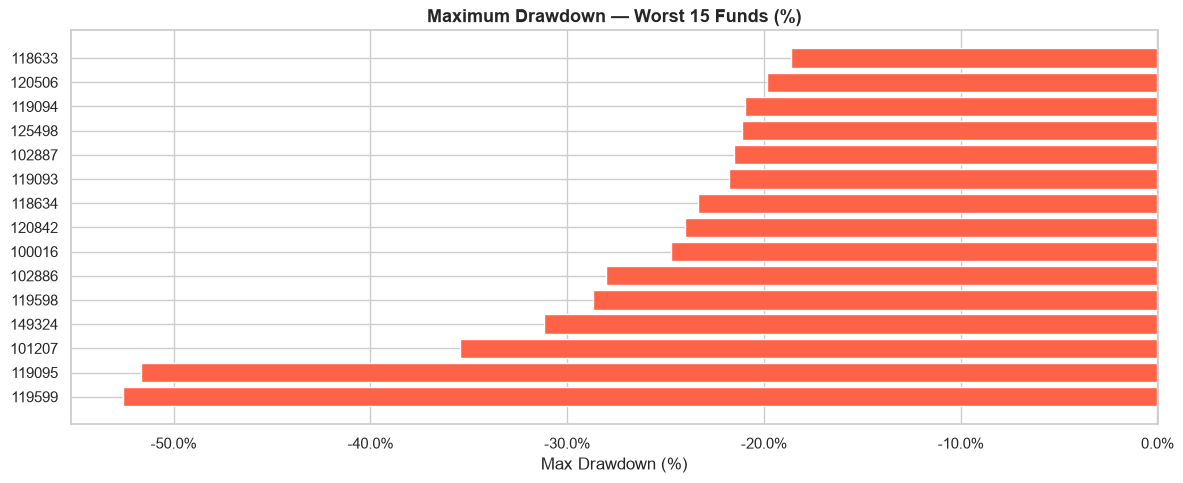

In [16]:
def max_drawdown(nav_series):
    """min(NAV / running_max - 1). Returns (max_dd, start_date, end_date)"""
    s = nav_series.dropna()
    if len(s) < 2:
        return np.nan, None, None
    running_max = s.cummax()
    drawdown    = s / running_max - 1
    min_dd      = drawdown.min()
    end_date    = drawdown.idxmin()
    # Find start = last peak before end_date
    start_date  = running_max[:end_date].idxmax()
    return min_dd, start_date, end_date

dd_rows = []
for code in schemes:
    s = nav_wide[code]
    dd, sd, ed = max_drawdown(s)
    dd_rows.append({
        'scheme_code':    code,
        'max_drawdown':   dd,
        'drawdown_start': sd,
        'drawdown_end':   ed
    })

dd_df = pd.DataFrame(dd_rows).sort_values('max_drawdown')
print('Maximum Drawdown — Worst 10 Funds:')
print(dd_df.head(10).to_string(index=False))

# Chart — worst 15 drawdowns
dd_plot = dd_df.dropna().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(dd_plot['scheme_code'].astype(str), dd_plot['max_drawdown'] * 100, color='tomato')
ax.set_title('Maximum Drawdown — Worst 15 Funds (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Max Drawdown (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
save_png(fig, '13_maximum_drawdown.png')
plt.show()

---
## Step 7 — Fund Scorecard (0–100)

Fund Scorecard — Top 20:
      scheme_code                                            scheme_name  cagr_3yr  sharpe_ratio    alpha  expense_ratio  max_drawdown  composite_score
rank                                                                                                                                                   
1          120505               ICICI Pru Midcap Fund - Regular - Growth  0.317775      1.180101  29.2636           1.36     -0.181885            84.50
2          119094                    Axis Midcap Fund - Regular - Growth  0.351118      0.998231  26.0767           1.38     -0.209609            80.75
3          100033     HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.324425      1.093699  27.1954           1.38     -0.162172            80.50
4          148567          Mirae Asset Large Cap Fund - Regular - Growth  0.340009      1.448291  26.9838           1.46     -0.112657            80.00
5          120843                 Kotak Flexicap Fund - Regular

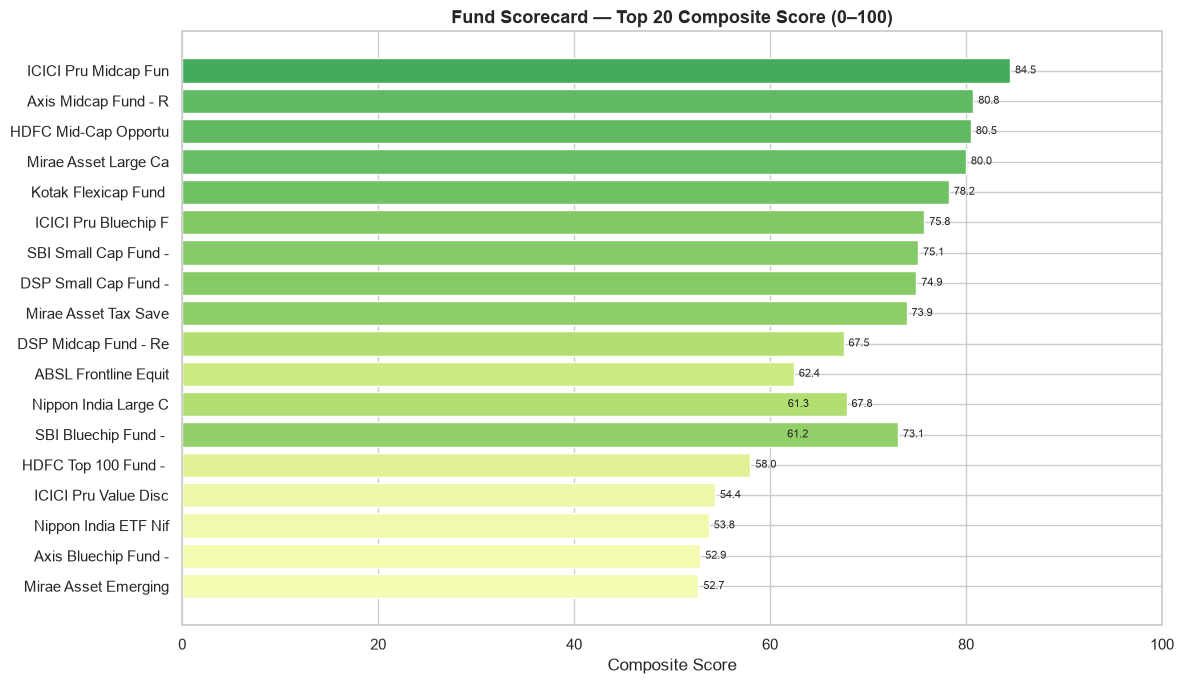

In [17]:
# Merge all metrics
scorecard = cagr_df[['scheme_code','cagr_3yr']].copy()
scorecard = scorecard.merge(sharpe_df[['scheme_code','sharpe_ratio']],   on='scheme_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['scheme_code','alpha']],       on='scheme_code', how='left')
scorecard = scorecard.merge(dd_df[['scheme_code','max_drawdown']],        on='scheme_code', how='left')

# Merge expense ratio from perf if available
exp_col = next((c for c in perf.columns if 'expense' in c.lower() or 'ter' in c.lower()), None)
pc      = next((c for c in perf.columns if 'code'   in c.lower() or 'amfi' in c.lower()), None)
if exp_col and pc:
    exp_avg = perf.groupby(pc)[exp_col].mean().reset_index()
    exp_avg.columns = ['scheme_code', 'expense_ratio']
    scorecard = scorecard.merge(exp_avg, on='scheme_code', how='left')
else:
    scorecard['expense_ratio'] = np.nan

def rank_pct(series, ascending=True):
    """Rank as percentile 0–100. ascending=True means higher value = higher rank."""
    return series.rank(ascending=ascending, pct=True) * 100

scorecard['rank_3yr_return']    = rank_pct(scorecard['cagr_3yr'],      ascending=True)
scorecard['rank_sharpe']        = rank_pct(scorecard['sharpe_ratio'],   ascending=True)
scorecard['rank_alpha']         = rank_pct(scorecard['alpha'],          ascending=True)
scorecard['rank_expense']       = rank_pct(scorecard['expense_ratio'],  ascending=False)  # lower is better
scorecard['rank_max_dd']        = rank_pct(scorecard['max_drawdown'],   ascending=False)  # less negative is better

# Composite score: 30/25/20/15/10
scorecard['composite_score'] = (
    0.30 * scorecard['rank_3yr_return'].fillna(50) +
    0.25 * scorecard['rank_sharpe'].fillna(50)     +
    0.20 * scorecard['rank_alpha'].fillna(50)      +
    0.15 * scorecard['rank_expense'].fillna(50)    +
    0.10 * scorecard['rank_max_dd'].fillna(50)
).round(2)

# Merge names
if 'scheme_name' in funds.columns:
    fc = [c for c in funds.columns if 'code' in c.lower() or 'amfi' in c.lower()][0]
    scorecard = scorecard.merge(funds[[fc,'scheme_name']], left_on='scheme_code', right_on=fc, how='left')

scorecard_sorted = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
scorecard_sorted.index += 1
scorecard_sorted.index.name = 'rank'

display_cols = ['scheme_code'] + (['scheme_name'] if 'scheme_name' in scorecard_sorted.columns else []) + \
               ['cagr_3yr','sharpe_ratio','alpha','expense_ratio','max_drawdown','composite_score']

print('Fund Scorecard — Top 20:')
print(scorecard_sorted[display_cols].head(20).to_string())

scorecard_sorted.to_csv('fund_scorecard.csv')
print('\n✓ fund_scorecard.csv saved')

# Chart — top 20 by score
top20 = scorecard_sorted.head(20)
label = top20['scheme_name'].str[:20] if 'scheme_name' in top20.columns else top20['scheme_code'].astype(str)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(label[::-1], top20['composite_score'][::-1],
               color=plt.cm.RdYlGn(top20['composite_score'][::-1] / 100))
ax.set_title('Fund Scorecard — Top 20 Composite Score (0–100)', fontsize=13, fontweight='bold')
ax.set_xlabel('Composite Score')
ax.set_xlim(0, 100)
for bar, val in zip(bars, top20['composite_score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)
plt.tight_layout()
save_png(fig, '14_fund_scorecard.png')
plt.show()

---
## Step 8 — Benchmark Comparison Chart

  ✓ Saved 15_benchmark_comparison.png


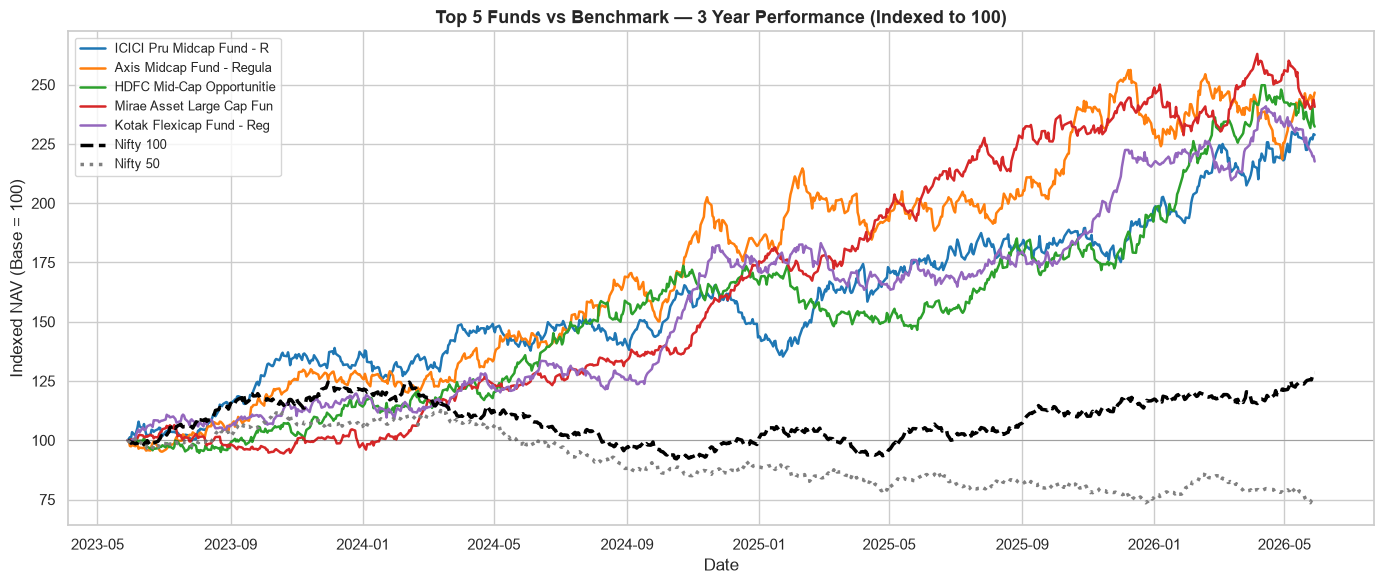


Tracking Error vs Nifty 100 (annualised):
  ICICI Pru Midcap Fund - Regula  : 23.27%
  Axis Midcap Fund - Regular - G  : 23.98%
  HDFC Mid-Cap Opportunities Fun  : 22.50%
  Mirae Asset Large Cap Fund - R  : 18.80%
  Kotak Flexicap Fund - Regular   : 20.65%


In [20]:
# Top 5 funds by composite score
top5_codes = scorecard_sorted['scheme_code'].head(5).tolist()

# Filter last 3 years
cutoff   = nav_wide.index.max() - pd.DateOffset(years=3)
nav_3yr  = nav_wide[nav_wide.index >= cutoff][top5_codes].copy()

# Benchmark — use bench_pivot from Step 5
bench_3yr = bench_pivot[[nifty100_col]].copy()
if nifty50_col:
    bench_3yr[nifty50_col] = bench_pivot[nifty50_col]
bench_3yr = bench_3yr[bench_3yr.index >= cutoff]

# Normalise everything to 100 at start
def normalise(df):
    first = df.iloc[0].replace(0, np.nan)
    return df / first * 100

nav_norm   = normalise(nav_3yr)
bench_norm = normalise(bench_3yr)

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10.colors
for i, code in enumerate(top5_codes):
    label = str(code)
    if 'scheme_name' in scorecard_sorted.columns:
        row = scorecard_sorted[scorecard_sorted['scheme_code'] == code]
        if not row.empty:
            label = str(row['scheme_name'].values[0])[:25]
    if code in nav_norm.columns:
        ax.plot(nav_norm.index, nav_norm[code], label=label, linewidth=1.8, color=colors[i])

# Plot benchmarks
if nifty100_col in bench_norm.columns:
    ax.plot(bench_norm.index, bench_norm[nifty100_col], label='Nifty 100',
            linewidth=2.5, color='black', linestyle='--')
if nifty50_col and nifty50_col in bench_norm.columns:
    ax.plot(bench_norm.index, bench_norm[nifty50_col], label='Nifty 50',
            linewidth=2.5, color='gray', linestyle=':')

ax.axhline(100, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_title('Top 5 Funds vs Benchmark — 3 Year Performance (Indexed to 100)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed NAV (Base = 100)')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
save_png(fig, '15_benchmark_comparison.png')
plt.show()

# Tracking Error
print('\nTracking Error vs Nifty 100 (annualised):')
bench_ret_3yr = bench_3yr[nifty100_col].pct_change().dropna()
for code in top5_codes:
    if code not in returns.columns:
        continue
    fund_ret_3yr = returns[code][returns.index >= cutoff]
    merged = pd.concat([fund_ret_3yr, bench_ret_3yr], axis=1).dropna()
    merged.columns = ['fund', 'bench']
    te = (merged['fund'] - merged['bench']).std() * np.sqrt(TRADING_DAYS)
    label = str(code)
    if 'scheme_name' in scorecard_sorted.columns:
        row = scorecard_sorted[scorecard_sorted['scheme_code'] == code]
        if not row.empty:
            label = str(row['scheme_name'].values[0])[:30]
    print(f'  {label:<32}: {te:.2%}')

In [19]:
# Final summary
print('='*55)
print('DAY 4 DELIVERABLES SUMMARY')
print('='*55)
print(f'fund_scorecard.csv  — {len(scorecard_sorted)} funds ranked')
print(f'alpha_beta.csv      — {len(alpha_beta_df)} funds')
charts = [f for f in os.listdir(CHARTS) if f.startswith('1')]
print(f'Charts saved        — {len(charts)} files in reports/charts/')
for c in sorted(charts):
    print(f'  {c}')

DAY 4 DELIVERABLES SUMMARY
fund_scorecard.csv  — 40 funds ranked
alpha_beta.csv      — 40 funds
Charts saved        — 5 files in reports/charts/
  10_expense_ratio_distribution.png
  11_daily_return_distribution.png
  12_sharpe_ratio_ranking.png
  13_maximum_drawdown.png
  14_fund_scorecard.png
